# Opening the published ECMWF IFS Icechunk store (source.coop)

The ECMWF IFS ensemble GIK store is published on **source.coop** as a virtual
Icechunk repo. Its metadata (repo pointer + snapshots + manifests + transactions)
lives on source.coop; the actual data chunks are **virtual references** into the
public `s3://ecmwf-forecasts/` GRIB archive on AWS. A reader needs only:

- **anonymous** GET/LIST on source.coop (the store metadata), and
- **anonymous** GET on `ecmwf-forecasts` (the GRIB bytes the virtual chunks point at).

| | value |
|---|---|
| Endpoint | `https://data.source.coop` |
| Bucket | `e4drr-project` |
| Prefix | `forecasts/ecmwf_ifs_ens_aws_s3_icechunk_vd` |
| Groups | `0p4/00z`, `49r1/00z`, `50r1/00z`  &larr; **one group per schema era** |
| Virtual chunk source | `s3://ecmwf-forecasts/` (anonymous) |
| Chunk codec | `gribberish` (Zarr v3) |

## The store is multi-era (three groups, not one)

Unlike [GEFS](https://gist.github.com/nishadhka/8f2c3191b51aa7e7670c8979081484bc) (a single `0p25/00z` group), the ECMWF store keeps each schema era in its
own group because grid, level count, and variable set differ:

| Group | Grid | pl levels | Data vars | Window (00z) |
|---|---|---|---|---|
| `0p4/00z`  | 451 x 900  | 9  | 19 | 2023-01-18 .. 2024-02-28 |
| `49r1/00z` | 721 x 1440 | 13 | 59 | 2024-02-29 .. 2026-05-12 |
| `50r1/00z` | 721 x 1440 | 14 | 54 | 2026-05-12 .. present |

All three share `number=51` (control + 50 perturbed) and `step=85`.

Coverage is **complete**: for every era the store references 100% of the pl params and
levels ECMWF publishes in `enfo` (0p4 has only 8 pl params -- no `w` -- because
0p4-beta never published it), plus all sfc/sol params. Referenced bytes are 97-100% of
published `enfo` bytes, date for date.

## Dependencies

```
icechunk>=2.1  zarr>=3.2  xarray>=2025.1  gribberish>=1.4  s3fs  numpy  matplotlib
```

No credentials of any kind are required: this notebook reads the store metadata
anonymously from source.coop and the GRIB bytes anonymously from AWS.


In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import icechunk
import xarray as xr
import gribberish.zarr  # noqa: F401 -- registers the "gribberish" Zarr v3 codec

print("icechunk", icechunk.__version__)
print("xarray  ", xr.__version__)

icechunk 2.1.1
xarray   2026.7.0


## Open the store

Same anonymous path as GEFS -- `force_path_style=True`, `from_env=False`, manifest
preload off, and `decode_timedelta=True` on `open_zarr`. All four are explained in
**Gotchas** at the bottom. The repo is opened once; each era is then a separate
`open_zarr` call against the same session.

In [2]:
ENDPOINT = "https://data.source.coop"
BUCKET = "e4drr-project"
PREFIX = "forecasts/ecmwf_ifs_ens_aws_s3_icechunk_vd"
CONTAINER = "s3://ecmwf-forecasts/"     # virtual chunks (public AWS, anon)
ERAS = ["0p4", "49r1", "50r1"]          # each has a 00z group holding the arrays

t0 = time.time()

storage = icechunk.s3_storage(
    bucket=BUCKET,
    prefix=PREFIX,
    endpoint_url=ENDPOINT,
    region="us-east-1",
    anonymous=True,         # public read of the store metadata
    from_env=False,         # ignore any AWS_* env vars
    force_path_style=True,  # source.coop needs path-style addressing
)

# authorize anonymous byte-range reads of the virtual chunks on AWS
auth = icechunk.containers_credentials(
    {CONTAINER: icechunk.s3_anonymous_credentials()})

# Disable eager manifest preload -- see "source.coop sporadic 500s" in Gotchas.
cfg = icechunk.RepositoryConfig.default()
cfg.manifest = icechunk.ManifestConfig(
    preload=icechunk.ManifestPreloadConfig(max_total_refs=0, max_arrays_to_scan=0))

repo = icechunk.Repository.open(
    storage, config=cfg, authorize_virtual_chunk_access=auth)
sess = repo.readonly_session("main")

print(f"repo opened in {time.time() - t0:.1f}s")

repo opened in 3.5s


### `decode_timedelta=True` is what silences the FutureWarning

`step` is stored with a timedelta-like `units` attribute but no `dtype` attribute.
Historically xarray decoded that into `timedelta64[ns]` by guessing from `units`; that
guess is being removed, so xarray warns unless you state your intent:

```
FutureWarning: In a future version, xarray will not decode the variable 'step'
into a timedelta64 dtype based on the presence of a timedelta-like 'units'
attribute by default...
  ds = xr.open_zarr(sess.store, group="50r1/00z", ...
```

Passing `decode_timedelta=True` keeps today's behaviour (`step` stays a real
`timedelta64[ns]`, so `ds.step` prints as `0 days`, `0 days 03:00:00`, ...) and is
forward-compatible. Passing `False` would instead give you raw integer nanoseconds.
`True` is what you want here.

In [3]:
def open_era(era):
    """Open one schema era. Arrays live under `{era}/00z`, never the root."""
    return xr.open_zarr(
        sess.store,
        group=f"{era}/00z",
        consolidated=False,
        zarr_format=3,
        decode_timedelta=True,   # `step` carries timedelta-like units -- say so
    )


eras = {era: open_era(era) for era in ERAS}

for era, d in eras.items():
    ny, nx = d.sizes["latitude"], d.sizes["longitude"]
    print(f"{era:5s} {len(d.data_vars):2d} vars  grid {ny}x{nx}  "
          f"time={d.sizes['time']:4d}  number={d.sizes['number']}  "
          f"step={d.sizes['step']}  levels={d.sizes.get('isobaricInhPa')}  "
          f"| {np.datetime_as_string(d.time.values.min(), unit='D')} .. "
          f"{np.datetime_as_string(d.time.values.max(), unit='D')}")

0p4   19 vars  grid 451x900  time= 401  number=51  step=85  levels=9  | 2023-01-18 .. 2024-02-28
49r1  59 vars  grid 721x1440  time= 794  number=51  step=85  levels=13  | 2024-02-29 .. 2026-05-12
50r1  54 vars  grid 721x1440  time=  51  number=51  step=85  levels=14  | 2026-05-13 .. 2026-07-02


## The current era: `50r1/00z`

In [4]:
ds = eras["50r1"]
print(ds)

<xarray.Dataset> Size: 169TB
Dimensions:        (time: 51, number: 51, step: 85, latitude: 721,
                    longitude: 1440, isobaricInhPa: 14)
Coordinates:
  * time           (time) datetime64[ns] 408B 2026-05-13 ... 2026-07-02
  * number         (number) int16 102B 0 1 2 3 4 5 6 7 ... 44 45 46 47 48 49 50
  * step           (step) timedelta64[ns] 680B 0 days 00:00:00 ... 15 days 00...
  * latitude       (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude      (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
  * isobaricInhPa  (isobaricInhPa) float64 112B 10.0 50.0 100.0 ... 925.0 1e+03
Data variables: (12/54)
    100v           (time, number, step, latitude, longitude) float32 918GB dask.array<chunksize=(1, 1, 1, 721, 1440), meta=np.ndarray>
    10fg           (time, number, step, latitude, longitude) float32 918GB dask.array<chunksize=(1, 1, 1, 721, 1440), meta=np.ndarray>
    asn            (time, number, step, latitude, longitude) float32

## Size: three numbers, don't conflate them

| measure | size | meaning |
|---|---|---|
| store objects on source.coop | 15 GB | what is actually hosted |
| **referenced GRIB** (packed) | **~620 TB** | bytes pulled if you read the whole store once |
| enfo published, same 1246 dates | ~627 TB | what ECMWF put on S3 |
| dense float32 (`ds.nbytes`) | 2.79 PB | 234 TB + 2.39 PB + 169 TB -- **misleading** |

`ds.nbytes` assumes every cell exists, uncompressed. Use the referenced number for
"how much data is this".

In [5]:
total = 0
for era, d in eras.items():
    total += d.nbytes
    print(f"{era:5s} dense float32 (ds.nbytes): {d.nbytes / 1e12:8.1f} TB  "
          f"({d.nbytes:,} bytes)")
print(f"{'all':5s} dense float32, materialized: {total / 1e15:8.2f} PB")
print()
print("store objects on source.coop : ~15 GB   (what is actually hosted)")
print("referenced GRIB (packed)     : ~620 TB  (97-100% of enfo published)")
print("enfo published, same dates   : ~627 TB")

0p4   dense float32 (ds.nbytes):    234.3 TB  (234,255,938,612,870 bytes)
49r1  dense float32 (ds.nbytes):   2387.2 TB  (2,387,172,614,021,326 bytes)
50r1  dense float32 (ds.nbytes):    168.9 TB  (168,940,917,752,990 bytes)
all   dense float32, materialized:     2.79 PB

store objects on source.coop : ~15 GB   (what is actually hosted)
referenced GRIB (packed)     : ~620 TB  (97-100% of enfo published)
enfo published, same dates   : ~627 TB


## Read one field

This resolves a virtual chunk: icechunk maps the index to a byte range in a GRIB file
on `ecmwf-forecasts`, fetches just those bytes, and gribberish decodes the message.

In [6]:
ti = int(np.argmax(ds["time"].values))          # newest run in 50r1
newest = np.datetime_as_string(ds["time"].values[ti], unit="D")

t1 = time.time()
t2m = ds["t2m"].isel(time=ti, number=0, step=0).compute()   # control member, f000
print(f"t2m @ {newest}, member 0 (control), f000")
print(f"  shape {t2m.shape} decoded in {time.time() - t1:.2f}s")
print(f"  finite fraction {np.isfinite(t2m.values).mean():.3f}")
print(f"  min/mean/max = {float(t2m.min()):.4g} / {float(t2m.mean()):.4g} / "
      f"{float(t2m.max()):.4g} K")

t2m @ 2026-07-02, member 0 (control), f000
  shape (721, 1440) decoded in 1.95s
  finite fraction 1.000
  min/mean/max = 199.2 / 282.1 / 313.1 K


In [7]:
def plot_field(field, title, cbar_label, cmap="viridis", levels=21):
    """Filled contour of a (latitude, longitude) DataArray on a plain lat/lon grid."""
    fig, ax = plt.subplots(figsize=(12, 5.5))
    m = ax.contourf(field["longitude"], field["latitude"], field.values,
                    levels=levels, cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel("longitude (deg east)")
    ax.set_ylabel("latitude (deg north)")
    ax.set_aspect("equal")
    fig.colorbar(m, ax=ax, label=cbar_label, shrink=0.85)
    plt.tight_layout()
    plt.show()

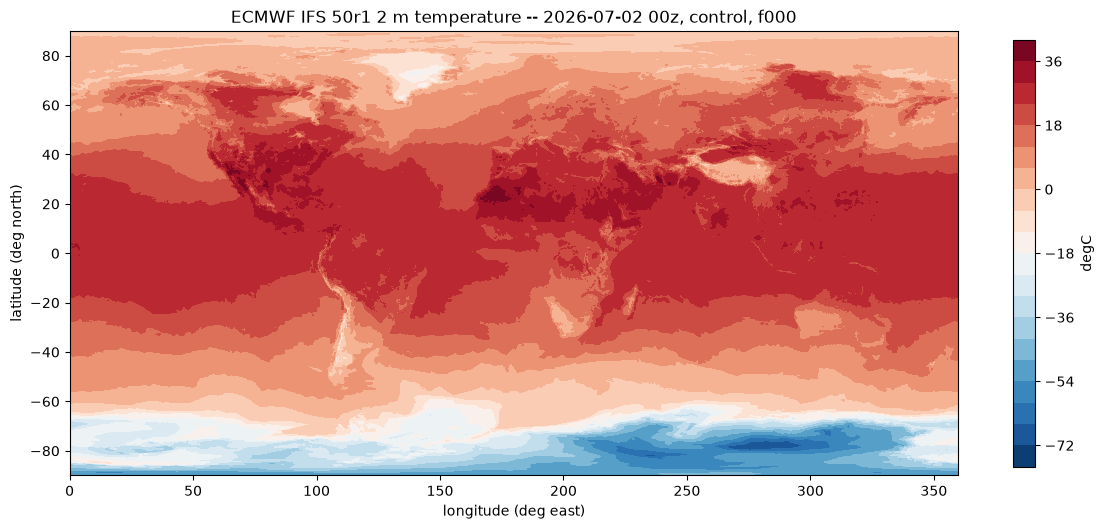

In [8]:
plot_field(t2m - 273.15,
           f"ECMWF IFS 50r1 2 m temperature -- {newest} 00z, control, f000",
           "degC", cmap="RdBu_r")

## The height layer

Unlike GEFS (single-level only), the ECMWF store has a real vertical dimension:
`isobaricInhPa`. In `50r1` that is 14 pressure levels from 10 to 1000 hPa, and the
3-D variables (`gh`, `t`, `u`, `v`, `w`, `q`, `r`, `d`, `vo`) carry it as a
dimension: `(time, number, step, isobaricInhPa, latitude, longitude)`.

Below we select the **500 hPa** level and decode geopotential height there -- the
classic mid-tropospheric chart. Selecting a level costs one chunk, not the whole
column.

In [11]:
print("levels (hPa):", ds["isobaricInhPa"].values)
print()
print("3-D vars (have isobaricInhPa):")
print("  ", ", ".join(sorted(v for v in ds.data_vars
                             if "isobaricInhPa" in ds[v].dims)))
print("gh dims:", ds["gh"].dims)

levels (hPa): [  10.   50.  100.  150.  200.  250.  300.  400.  500.  600.  700.  850.
  925. 1000.]

3-D vars (have isobaricInhPa):
   d, gh, q, r, t, u, v, vo, w, z
gh dims: ('time', 'number', 'step', 'isobaricInhPa', 'latitude', 'longitude')


In [12]:
t1 = time.time()
gh500 = ds["gh"].sel(isobaricInhPa=500).isel(time=ti, number=0, step=0).compute()
print(f"gh @ 500 hPa decoded in {time.time() - t1:.2f}s -- shape {gh500.shape}")
print(f"  min/mean/max = {float(gh500.min()):.0f} / {float(gh500.mean()):.0f} / "
      f"{float(gh500.max()):.0f} m")

gh @ 500 hPa decoded in 4.19s -- shape (721, 1440)
  min/mean/max = 4579 / 5558 / 5998 m


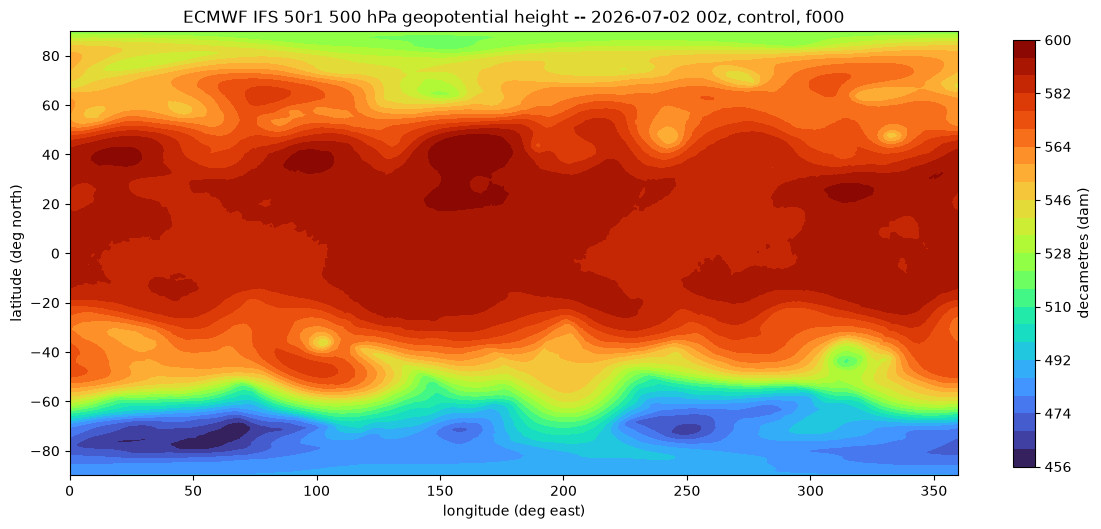

In [13]:
plot_field(gh500 / 10.0,
           f"ECMWF IFS 50r1 500 hPa geopotential height -- {newest} 00z, control, f000",
           "decametres (dam)", cmap="turbo", levels=25)

### The whole vertical column, for free

Because the level is just another dimension, a profile is an ordinary selection. This
pulls all 14 levels at one grid point -- 14 chunk resolutions, still no full array.

14-level temperature profile decoded in 5.8s


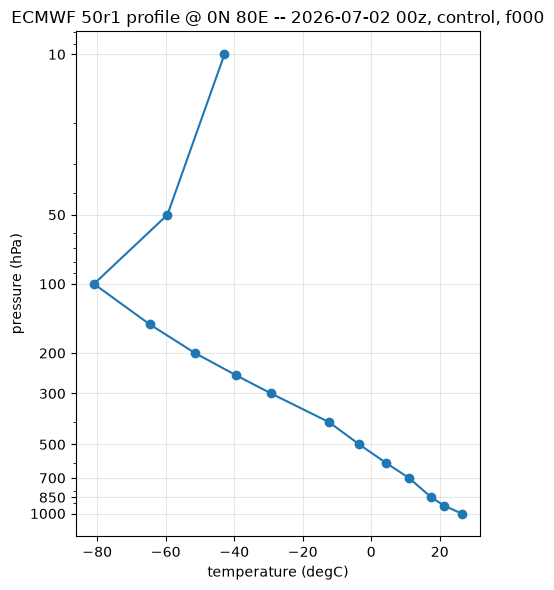

In [14]:
t1 = time.time()
prof = ds["t"].isel(time=ti, number=0, step=0).sel(
    latitude=0, longitude=80, method="nearest").compute()
print(f"14-level temperature profile decoded in {time.time() - t1:.1f}s")

fig, ax = plt.subplots(figsize=(5, 6))
ax.plot(prof.values - 273.15, prof["isobaricInhPa"].values, marker="o")
ax.invert_yaxis()
ax.set_yscale("log")
ax.set_yticks([10, 50, 100, 200, 300, 500, 700, 850, 1000])
ax.set_yticklabels([10, 50, 100, 200, 300, 500, 700, 850, 1000])
ax.set_xlabel("temperature (degC)")
ax.set_ylabel("pressure (hPa)")
ax.set_title(f"ECMWF 50r1 profile @ 0N 80E -- {newest} 00z, control, f000")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Gotchas

- **Arrays are under `{era}/00z`, never the root.** Opening the root group is empty;
  opening a bare `era` group is empty too -- you need `50r1/00z` etc.
- **Pass `decode_timedelta=True`.** Otherwise xarray raises a `FutureWarning` about
  decoding `step` from its `units` attribute. See the note above.
- **Variable names can differ by era.** In this store all three eras happen to expose
  2 m temperature as `t2m`, but the raw ECMWF short name (`2t`, `10u`) shows up in
  other GIK builds. Probe with `next(v for v in ("t2m", "2t") if v in ds)` rather than
  hard-coding, if you write code meant to survive a rebuild.
- **`gribberish.zarr` must be imported** before reading any chunk (registers the Zarr
  v3 codec) -- otherwise even opening a group fails with
  `UnknownCodecError: 'gribberish'` while reading array metadata.
- **Reading a 49r1 pressure-level variable needs >6 GB RAM.** Resolving *any* chunk
  makes icechunk load that array's **entire manifest**. Cost is ~200 bytes per
  chunk-ref, and refs = `dates x members x steps x levels`:

  | array | chunk-refs | peak RSS |
  |---|---|---|
  | `50r1/t2m` | 221 K | 0.25 GB |
  | `50r1/t` (14 levels, 51 dates) | 3.10 M | 0.81 GB |
  | `49r1/t2m` (794 dates, 2D) | 3.44 M | 0.80 GB |
  | `49r1/t` (794 dates x 13 levels) | **44.7 M** | **~9.1 GB -> OOM** |

  That is why the 500 hPa cells above read from `50r1` and not `49r1`. This is *not*
  caused by turning preload off (preload only controls eager prefetch at open, and
  actually lowers memory). It is purely array size -- `50r1` will hit the same wall
  once it accumulates ~800 dates. The fix is `icechunk.ManifestSplittingConfig` (split
  along `time`) **at write time**, so a read loads one shard instead of the whole
  array manifest.
- **`force_path_style=True`** is required for source.coop.
- **`from_env=False`** so stray `AWS_*` env vars don't turn the anonymous read into a
  signed one.
- **Disable eager manifest preload (source.coop sporadic 500s).** source.coop returns
  transient `HTTP 500` ("service error") on a small % of GETs under concurrency. This
  is source.coop, *not* AWS S3 (manifests live on source.coop; the GRIB byte-range
  reads to `ecmwf-forecasts` are never even reached at open time), and it is *not* a
  rate limit (128-way concurrent GET bursts succeed). icechunk's default open
  **prefetches thousands of manifests in parallel**, so at a few-% error rate at least
  one *critical* fetch tends to draw a 500 and the open raises `IcechunkError: object
  store error service error` -- with hundreds of "Failure pre-loading manifest ...
  service error" lines on stderr. The `ManifestPreloadConfig(max_total_refs=0,
  max_arrays_to_scan=0)` above turns preload off: manifests load lazily on demand
  (with retry), the stderr noise disappears, and open is robust (slower, but
  reliable). The store itself is complete -- a full object-count check shows all
  46,154 manifests present, so the errors are transport-side, not missing data.